In [ ]:
Cell 1 — Title (Markdown)
# 🏠 House Price Prediction using Linear Regression

**Author:** Ragul E
**Project:** ml-leakage-pipeline-Ragul E

## 📌 Objective
Build a regression model to predict house prices based on:
- Area (sqft)
- Number of bedrooms
- Age of property

Evaluate the model and analyze residuals.

In [ ]:
Cell 2 — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
Cell 3 — Create Dataset

## 📊 Task 1: Create Synthetic Dataset

In [2]:
np.random.seed(42)

n = 60
area_sqft = np.random.randint(500, 3000, n)
num_bedrooms = np.random.randint(1, 5, n)
age_years = np.random.randint(0, 30, n)

price_lakhs = (
    area_sqft * 0.05 +
    num_bedrooms * 10 -
    age_years * 0.3 +
    np.random.normal(0, 5, n)
)

df = pd.DataFrame({
    "area_sqft": area_sqft,
    "num_bedrooms": num_bedrooms,
    "age_years": age_years,
    "price_lakhs": price_lakhs
})

df.head()

,area_sqft,num_bedrooms,age_years,price_lakhs
0,1360,2,1,87.173714
1,1794,2,0,104.923268
2,1630,2,15,94.926177
3,1595,4,22,106.156296
4,2138,2,22,118.579597


In [ ]:
Cell 4 — Train Model
## 🤖 Train Linear Regression Model

In [3]:
X = df[["area_sqft", "num_bedrooms", "age_years"]]
y = df["price_lakhs"]

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("\nCoefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef}")

Intercept: -3.583067353040718

Coefficients:
area_sqft: 0.05148623548694177
num_bedrooms: 9.965069427516195
age_years: -0.2457972921276621


In [ ]:
Cell 5 — Predictions
## 🔍 Predictions (Actual vs Predicted)

In [4]:
y_pred = model.predict(X)

comparison = pd.DataFrame({
    "Actual": y.head(),
    "Predicted": y_pred[:5]
})

comparison

,Actual,Predicted
0,87.173714,86.122554
1,104.923268,108.713378
2,94.926177,96.582676
3,106.156296,112.990216
4,118.579597,121.017103


In [ ]:
Cell 6 — Evaluation Metrics
## 📈 Task 2: Model Evaluation

In [5]:
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

# MAE shows the average absolute prediction error.
# RMSE gives higher weight to large errors, helping detect instability.
# R² indicates how much variance is explained by the model (closer to 1 is better).

MAE: 3.796985678627884
RMSE: 4.8636152484305
R²: 0.9835997815577289


In [ ]:
Cell 7 — Residual Plot
## 📉 Task 3: Residual Analysis

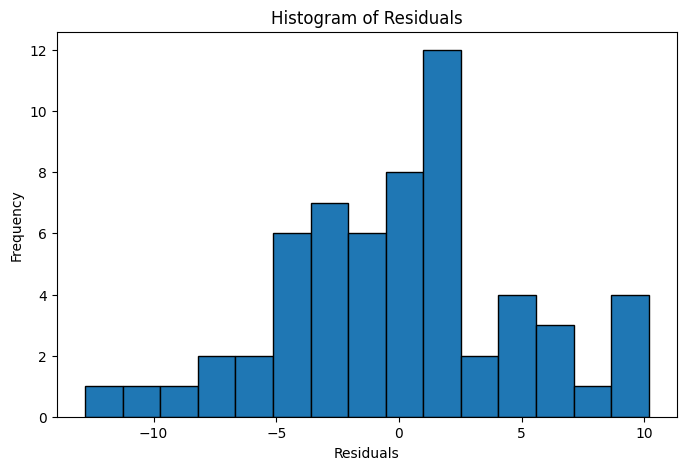

In [6]:
residuals = y - y_pred

plt.figure(figsize=(8,5))
plt.hist(residuals, bins=15, edgecolor='black')
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

In [ ]:
Cell 8 — Explanation (Markdown)
### 🧠 Residual Analysis Explanation

A residual is the difference between the actual value and the predicted value:
> Residual = Actual - Predicted

- If residuals are centered around zero → model is unbiased
- If distribution is symmetric → errors are normally distributed
- If skewed or wide → model may be missing important features

In this case, the histogram suggests how well the model fits the data.